# EDA: Marketing Strategy Deep Dive on Cleaned Starbucks Data

This notebook uses the new outputs from 01_b and 01_c to answer business-first questions for campaign strategy.

Primary goals:
1. Demographic response analysis (age, gender, income vs success).
2. Offer performance by type, channel, and value economics.
3. Spending behavior and transaction-related signals.
4. Funnel diagnosis and customer-level segmentation insights.
5. Practical modeling-readiness recommendations for next-stage ML.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)

# Resolve project root robustly whether current working directory is project root or notebooks/.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "features_added" / "preprocessed_data_features_added.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Expected EDA input file not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print(f"Loaded: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
df.head()

Loaded: d:\Desktop_informations\SGK năm 3\SGK kì 2 năm 3\PowerBI_DataDriven_Mkt\Project_data_driven_marketing\starbucks_reward_data_marketing\data\features_added\preprocessed_data_features_added.csv
Dataset shape: (50637, 50)
Rows: 50,637 | Columns: 50


,person,offer_id,time_completed,time_received,time_viewed,was_viewed,completed_after_view,within_offer_window,offer_success,received_not_viewed,age,income,days_since_registration,age_was_118,income_missing_before_impute,gender_missing_before_fill,age_missing_before_impute,reward,difficulty,channel_email,channel_mobile,channel_social,channel_web,channel_count,reward_to_difficulty,reward_per_day,offer_type_bogo,offer_type_discount,offer_type_informational,transaction_count,total_spent,avg_transaction_value,duration,time_completed_was_imputed,time_viewed_was_imputed,age_group,income_group,membership_duration_months,has_web_channel,has_email_channel,has_mobile_channel,has_social_channel,spend_per_transaction,spend_per_membership_day,difficulty_per_day,net_value_score,gender_F,gender_M,gender_O,gender_U
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576.0,576.0,360.0,0,False,True,0,1,33,72000.0,461,0,0,0,0,2,10,1,1,0,1,3,0.20,0.285714,0,1,0,8.0,127.60,15.950000,7,0,1,26-35,middle,15.14,1,1,1,0,15.950000,0.276790,1.428571,1.0,False,True,False,False
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,414.0,408.0,456.0,1,False,True,0,0,33,72000.0,461,0,0,0,0,5,5,1,1,1,1,4,1.00,1.000000,1,0,0,8.0,127.60,15.950000,5,0,0,26-35,middle,15.14,1,1,1,1,15.950000,0.276790,1.000000,4.5,False,True,False,False
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,528.0,504.0,540.0,1,False,True,0,0,33,72000.0,461,0,0,0,0,2,10,1,1,1,1,4,0.20,0.200000,0,1,0,8.0,127.60,15.950000,10,0,0,26-35,middle,15.14,1,1,1,1,15.950000,0.276790,1.000000,1.0,False,True,False,False
3,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,420.0,168.0,216.0,1,False,False,0,0,55,64000.0,92,1,1,1,1,5,5,1,1,1,1,4,1.00,1.000000,1,0,0,3.0,4.09,1.363333,5,1,0,46-55,middle,3.02,1,1,1,1,1.363333,0.044457,1.000000,4.5,False,False,False,True
4,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,576.0,408.0,432.0,1,True,True,1,0,40,57000.0,198,0,0,0,0,5,20,1,0,0,1,2,0.25,0.500000,0,1,0,5.0,79.46,15.892000,10,0,0,36-45,lower_middle,6.50,1,1,0,0,15.892000,0.401313,2.000000,3.0,False,False,True,False


In [2]:
# Basic quality profile + business critical fields
missing_rate = (df.isna().mean() * 100).sort_values(ascending=False)
duplicated_rows = int(df.duplicated().sum())

business_key_cols = [c for c in ['person', 'offer_id', 'offer', 'offer_success', 'age', 'income', 'reward', 'difficulty', 'duration'] if c in df.columns]

print("=== Data Quality Snapshot ===")
print(f"Duplicate rows: {duplicated_rows}")
print("\nTop missing-rate columns (%):")
print(missing_rate.head(12).round(2))
print("\nBusiness key columns present:", business_key_cols)

quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=False)
}).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

quality_summary.head(25)

=== Data Quality Snapshot ===
Duplicate rows: 0

Top missing-rate columns (%):
person                  0.0
offer_id                0.0
time_completed          0.0
time_received           0.0
time_viewed             0.0
was_viewed              0.0
completed_after_view    0.0
within_offer_window     0.0
offer_success           0.0
received_not_viewed     0.0
age                     0.0
income                  0.0
dtype: float64

Business key columns present: ['person', 'offer_id', 'offer_success', 'age', 'income', 'reward', 'difficulty', 'duration']


,dtype,missing_pct,n_unique
person,object,0.0,16928
spend_per_membership_day,float64,0.0,16393
avg_transaction_value,float64,0.0,14194
spend_per_transaction,float64,0.0,14194
total_spent,float64,0.0,11879
days_since_registration,int64,0.0,1714
membership_duration_months,float64,0.0,1714
time_completed,float64,0.0,120
time_viewed,float64,0.0,120
income,float64,0.0,91


## Demographic Strategy: Age, Gender, Income vs Offer Success

This section identifies which customer segments respond best, so campaign targeting can prioritize high-conversion groups and diagnose underperforming segments.

Using success column: offer_success
offer_success
0    30897
1    19740
Name: count, dtype: int64


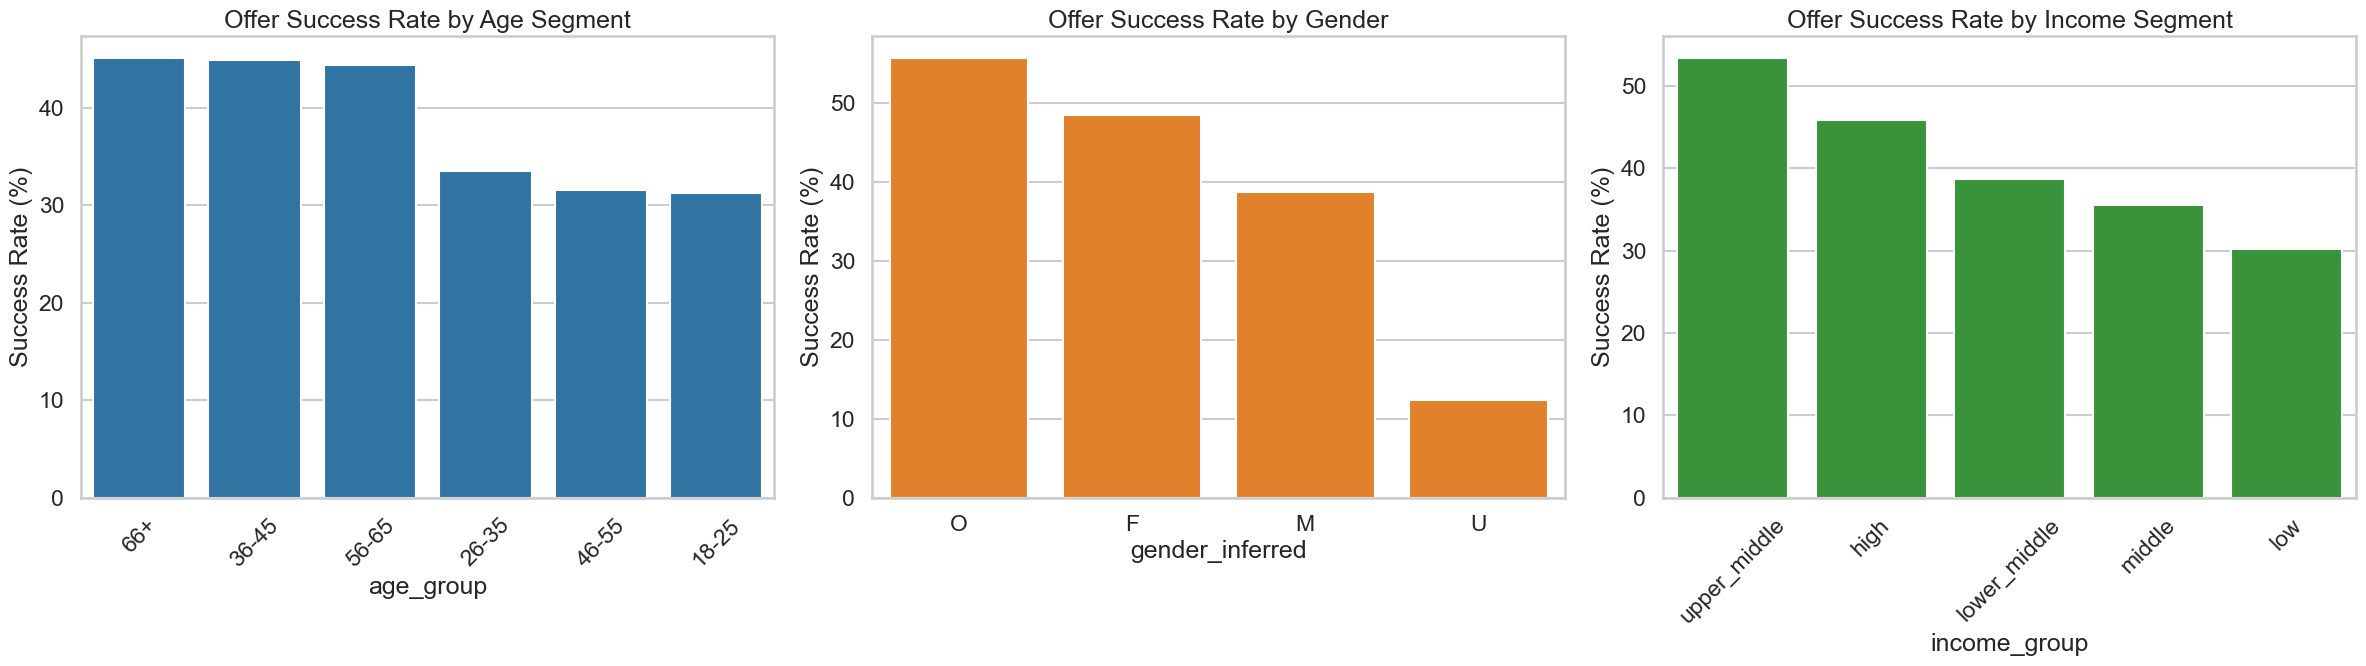

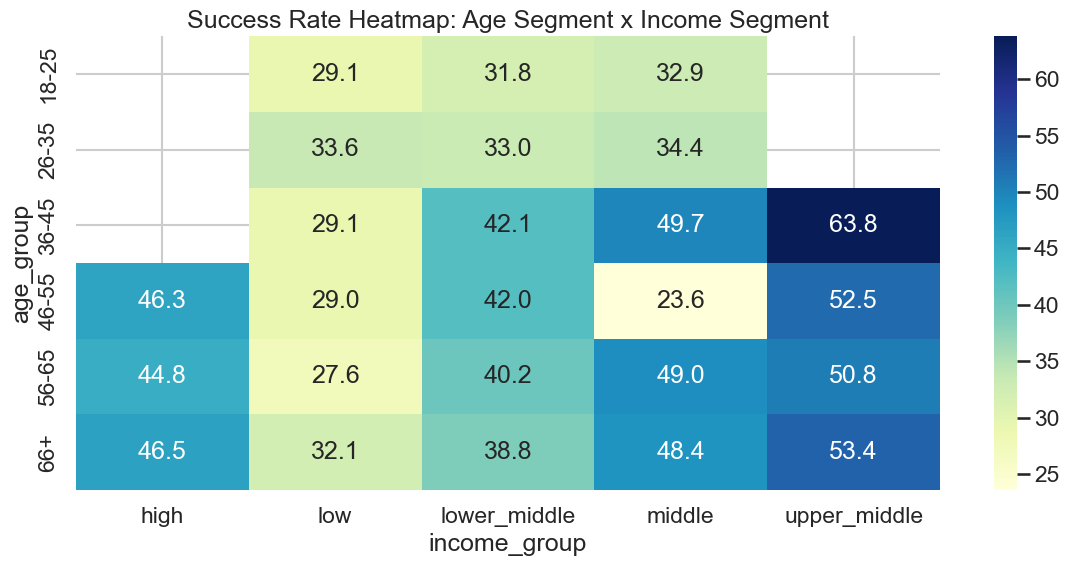

In [3]:
# Define a consistent binary success label from available columns
if "offer_success" in df.columns:
    success_col = "offer_success"
elif "offer_completed" in df.columns:
    success_col = "offer_completed"
elif "offer_completed_event" in df.columns:
    success_col = "offer_completed_event"
else:
    raise ValueError("No success indicator found: expected 'offer_success', 'offer_completed' or 'offer_completed_event'.")

df[success_col] = pd.to_numeric(df[success_col], errors="coerce").fillna(0).astype(int)
print(f"Using success column: {success_col}")
print(df[success_col].value_counts(dropna=False))

# Resolve demographic fields robustly
age_col = "age_group" if "age_group" in df.columns else ("age" if "age" in df.columns else None)
income_col = "income_group" if "income_group" in df.columns else ("income" if "income" in df.columns else None)
gender_col = "gender" if "gender" in df.columns else None

if gender_col is None:
    # Keep only true gender one-hot columns, exclude flags like gender_missing_before_fill
    gender_dummy_cols = [
        c for c in df.columns
        if c.startswith("gender_") and c.replace("gender_", "") in {"F", "M", "O", "U"}
    ]
    if gender_dummy_cols:
        df["gender_inferred"] = df[gender_dummy_cols].idxmax(axis=1).str.replace("gender_", "", regex=False)
        gender_col = "gender_inferred"

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

if age_col is not None:
    age_success = (
        df.groupby(age_col, observed=False)[success_col]
          .mean()
          .mul(100)
          .sort_values(ascending=False)
          .reset_index(name="success_rate")
    )
    sns.barplot(data=age_success, x=age_col, y="success_rate", ax=axes[0], color="#1f77b4")
    axes[0].set_title("Offer Success Rate by Age Segment")
    axes[0].set_ylabel("Success Rate (%)")
    axes[0].tick_params(axis="x", rotation=45)
else:
    axes[0].text(0.5, 0.5, "No age field found", ha="center", va="center")
    axes[0].set_axis_off()

if gender_col is not None:
    gender_success = (
        df.groupby(gender_col, observed=False)[success_col]
          .mean()
          .mul(100)
          .sort_values(ascending=False)
          .reset_index(name="success_rate")
    )
    sns.barplot(data=gender_success, x=gender_col, y="success_rate", ax=axes[1], color="#ff7f0e")
    axes[1].set_title("Offer Success Rate by Gender")
    axes[1].set_ylabel("Success Rate (%)")
else:
    axes[1].text(0.5, 0.5, "No gender field found", ha="center", va="center")
    axes[1].set_axis_off()

if income_col is not None:
    income_success = (
        df.groupby(income_col, observed=False)[success_col]
          .mean()
          .mul(100)
          .sort_values(ascending=False)
          .reset_index(name="success_rate")
    )
    sns.barplot(data=income_success, x=income_col, y="success_rate", ax=axes[2], color="#2ca02c")
    axes[2].set_title("Offer Success Rate by Income Segment")
    axes[2].set_ylabel("Success Rate (%)")
    axes[2].tick_params(axis="x", rotation=45)
else:
    axes[2].text(0.5, 0.5, "No income field found", ha="center", va="center")
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()

# Cross-segment heatmap
if age_col is not None and income_col is not None:
    demographic_table = (
        df.groupby([age_col, income_col], observed=False)[success_col]
          .mean()
          .mul(100)
          .round(2)
          .unstack(fill_value=np.nan)
    )
    plt.figure(figsize=(12, 6))
    sns.heatmap(demographic_table, annot=True, fmt=".1f", cmap="YlGnBu")
    plt.title("Success Rate Heatmap: Age Segment x Income Segment")
    plt.xlabel(income_col)
    plt.ylabel(age_col)
    plt.tight_layout()
    plt.show()
    demographic_table

## Offer Performance by Offer Type, Channel, and Campaign Economics

This section links campaign design decisions (offer type, channel mix, value intensity) with conversion outcomes.

,offer_type,success_rate,avg_reward,avg_difficulty,avg_duration,unique_offers,records
1,discount,41.63,3.01,11.77,8.51,4,25316
0,bogo,36.34,7.51,7.51,6.01,4,25321


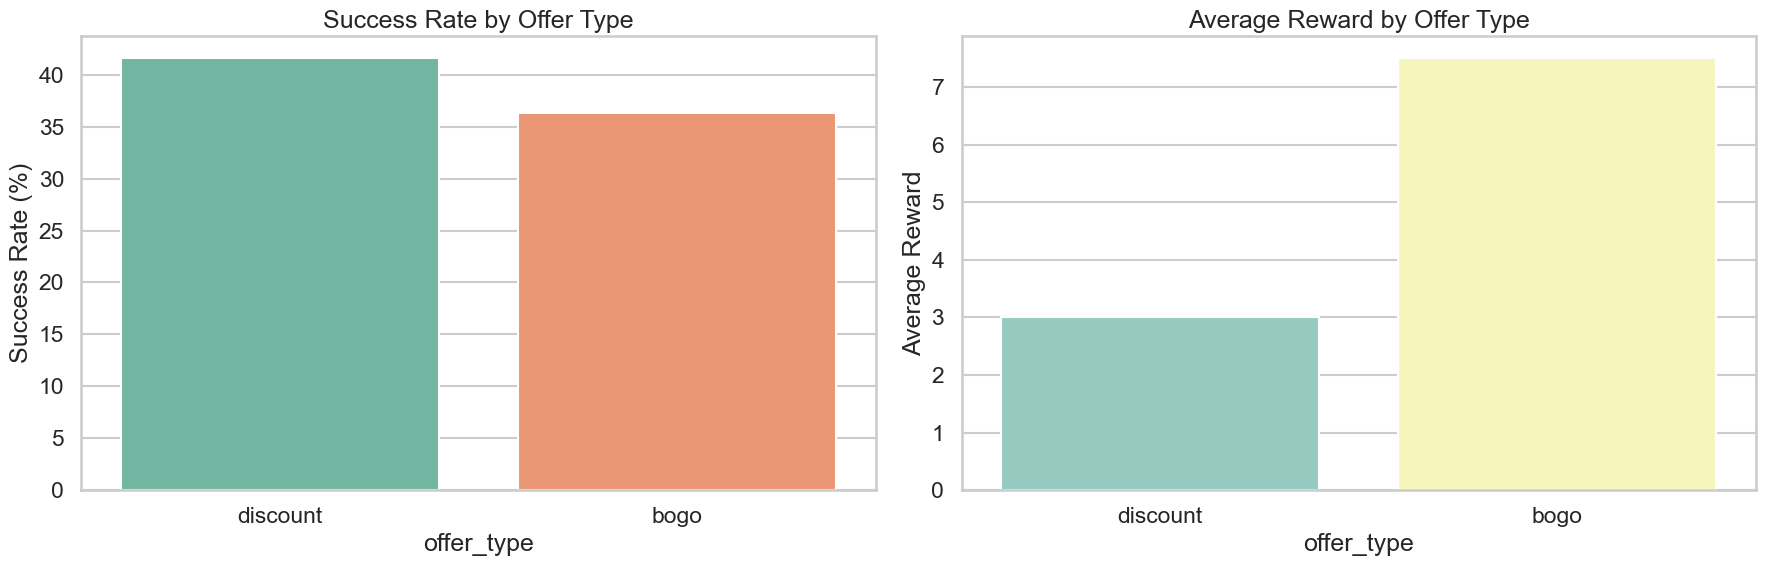

,channel,records,success_rate
3,has_social_channel,31623,47.53
7,channel_social,31623,47.53
6,channel_mobile,44263,41.98
2,has_mobile_channel,44263,41.98
4,channel_web,44263,39.63
0,has_web_channel,44263,39.63
1,has_email_channel,50637,38.98
5,channel_email,50637,38.98


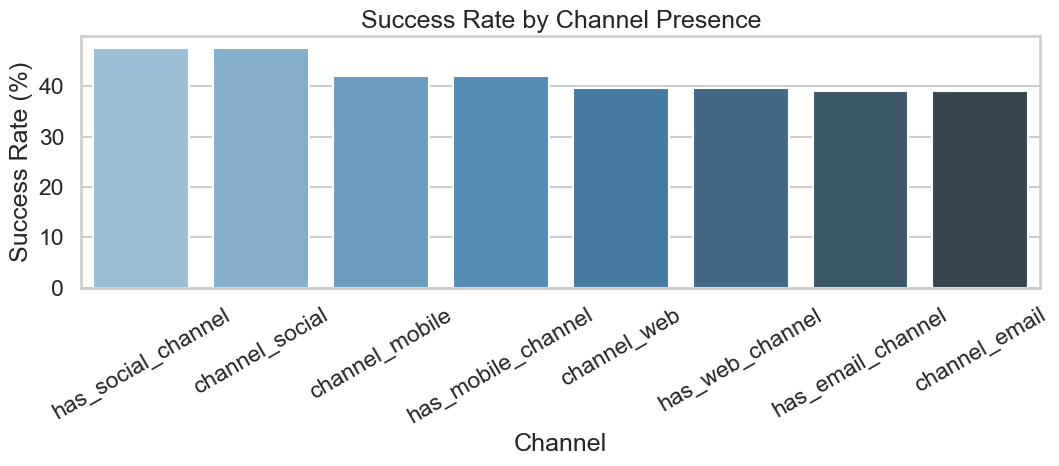

,reward_to_difficulty,reward_per_day,difficulty_per_day,net_value_score
offer_success,,,,
0,0.645,0.847,1.378,4.472
1,0.618,0.779,1.235,4.014


In [4]:
# Build offer_type from encoded columns when needed
if "offer_type" not in df.columns:
    if all(c in df.columns for c in ["offer_type_bogo", "offer_type_discount", "offer_type_informational"]):
        offer_type_map = {
            "offer_type_bogo": "bogo",
            "offer_type_discount": "discount",
            "offer_type_informational": "informational"
        }
        type_matrix = df[["offer_type_bogo", "offer_type_discount", "offer_type_informational"]].astype(int)
        df["offer_type"] = type_matrix.idxmax(axis=1).map(offer_type_map)
        df.loc[type_matrix.sum(axis=1) == 0, "offer_type"] = "unknown"
    else:
        df["offer_type"] = "unknown"

id_offer_col = "offer_id" if "offer_id" in df.columns else ("offer" if "offer" in df.columns else None)
record_counter_col = "person" if "person" in df.columns else df.columns[0]

agg_dict = {"success_rate": (success_col, "mean") }
if "reward" in df.columns:
    agg_dict["avg_reward"] = ("reward", "mean")
if "difficulty" in df.columns:
    agg_dict["avg_difficulty"] = ("difficulty", "mean")
if "duration" in df.columns:
    agg_dict["avg_duration"] = ("duration", "mean")
if id_offer_col is not None:
    agg_dict["unique_offers"] = (id_offer_col, "nunique")
agg_dict["records"] = (record_counter_col, "count")

offer_perf = df.groupby("offer_type", observed=False).agg(**agg_dict).reset_index()
offer_perf["success_rate"] = offer_perf["success_rate"] * 100
offer_perf = offer_perf.sort_values("success_rate", ascending=False)
display(offer_perf.round(2))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=offer_perf, x="offer_type", y="success_rate", hue="offer_type", ax=axes[0], palette="Set2", legend=False)
axes[0].set_title("Success Rate by Offer Type")
axes[0].set_ylabel("Success Rate (%)")

if "avg_reward" in offer_perf.columns:
    sns.barplot(data=offer_perf, x="offer_type", y="avg_reward", hue="offer_type", ax=axes[1], palette="Set3", legend=False)
    axes[1].set_title("Average Reward by Offer Type")
    axes[1].set_ylabel("Average Reward")
else:
    axes[1].text(0.5, 0.5, "Reward column not available", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

# Channel-level performance summary
channel_candidates = [
    c for c in ["has_web_channel", "has_email_channel", "has_mobile_channel", "has_social_channel", "channel_web", "channel_email", "channel_mobile", "channel_social", "web", "email", "mobile", "social"]
    if c in df.columns
]

channel_summary = []
for ch in channel_candidates:
    mask = pd.to_numeric(df[ch], errors="coerce").fillna(0).astype(int) == 1
    if mask.sum() > 0:
        channel_summary.append({
            "channel": ch,
            "records": int(mask.sum()),
            "success_rate": float(df.loc[mask, success_col].mean() * 100)
        })

channel_summary_df = pd.DataFrame(channel_summary).sort_values("success_rate", ascending=False)
display(channel_summary_df.round(2))

plt.figure(figsize=(11, 5))
sns.barplot(data=channel_summary_df, x="channel", y="success_rate", hue="channel", palette="Blues_d", legend=False)
plt.title("Success Rate by Channel Presence")
plt.ylabel("Success Rate (%)")
plt.xlabel("Channel")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Campaign economics vs success (if engineered columns exist)
econ_cols = [c for c in ["reward_to_difficulty", "reward_per_day", "difficulty_per_day", "net_value_score"] if c in df.columns]
if econ_cols:
    econ_table = (
        df.groupby(success_col, observed=False)[econ_cols]
          .mean()
          .round(3)
    )
    display(econ_table)

## Spending and Transaction Behavior Analysis

This section quantifies monetary behavior and spending intensity to support budget allocation and value-based segmentation.

Primary spending column used: avg_transaction_value
count    50637.00
mean        13.30
std         15.51
min          0.00
25%          3.04
50%         11.36
75%         20.27
90%         25.81
95%         28.61
99%         68.95
max        451.47
Name: avg_transaction_value, dtype: float64


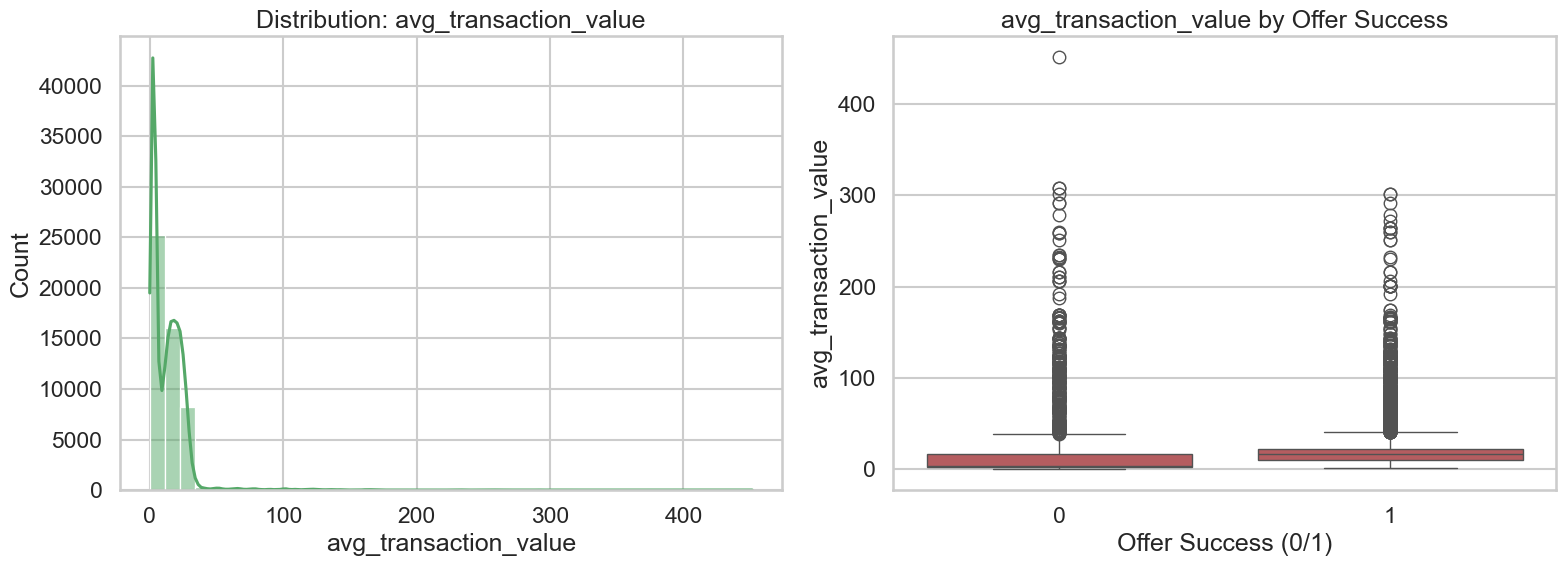

,avg_spend_metric
offer_success,
0,10.381
1,17.877


,tenure_band,success_rate,avg_spend,records
0,0-3m,22.46,10.20,5276
1,3-6m,23.80,10.52,5312
2,6-12m,32.08,12.30,15366
3,12-24m,51.86,16.20,10222
4,24m+,48.91,14.50,14394


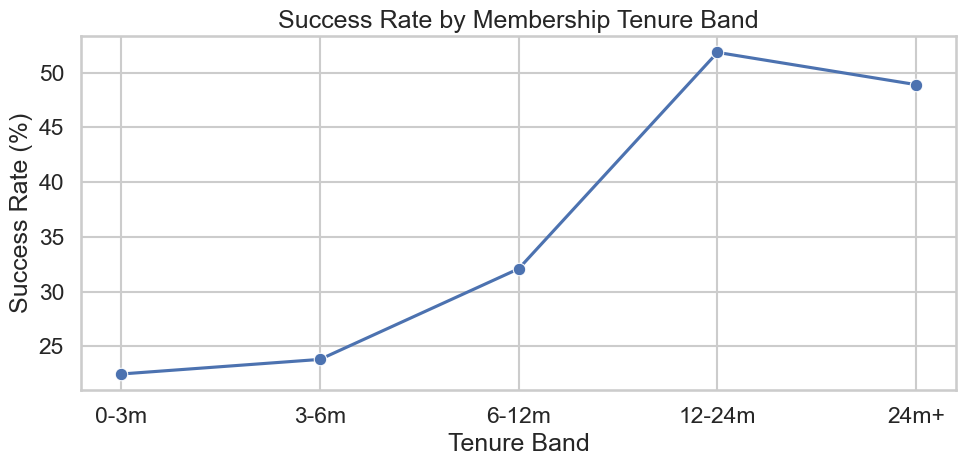

In [5]:
# Prefer business-relevant spending features from 01_b output
spend_candidates = [c for c in ["avg_transaction_value", "total_spent", "spend_per_transaction", "spend_per_membership_day"] if c in df.columns]

if spend_candidates:
    spend_col = spend_candidates[0]
    print(f"Primary spending column used: {spend_col}")
    print(df[spend_col].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.histplot(df[spend_col].dropna(), bins=40, kde=True, ax=axes[0], color="#55a868")
    axes[0].set_title(f"Distribution: {spend_col}")

    sns.boxplot(data=df, x=success_col, y=spend_col, ax=axes[1], color="#c44e52")
    axes[1].set_title(f"{spend_col} by Offer Success")
    axes[1].set_xlabel("Offer Success (0/1)")

    plt.tight_layout()
    plt.show()

    spend_success = df.groupby(success_col, observed=False)[spend_col].mean().rename("avg_spend_metric").to_frame()
    display(spend_success.round(3))

    # If tenure exists, inspect intensity over lifecycle
    if "membership_duration_months" in df.columns:
        tmp = df[["membership_duration_months", spend_col, success_col]].copy()
        tmp["tenure_band"] = pd.cut(tmp["membership_duration_months"], bins=[0, 3, 6, 12, 24, np.inf], labels=["0-3m", "3-6m", "6-12m", "12-24m", "24m+"])
        tenure_perf = tmp.groupby("tenure_band", observed=False).agg(
            success_rate=(success_col, "mean"),
            avg_spend=(spend_col, "mean"),
            records=(success_col, "count")
        ).reset_index()
        tenure_perf["success_rate"] = tenure_perf["success_rate"] * 100
        display(tenure_perf.round(2))

        plt.figure(figsize=(10, 5))
        sns.lineplot(data=tenure_perf, x="tenure_band", y="success_rate", marker="o")
        plt.title("Success Rate by Membership Tenure Band")
        plt.ylabel("Success Rate (%)")
        plt.xlabel("Tenure Band")
        plt.tight_layout()
        plt.show()
else:
    print("No spending proxy columns found in this dataset.")
    if "reward" in df.columns:
        print("Using reward as fallback proxy.")
        proxy = df.groupby(success_col, observed=False)["reward"].agg(["count", "mean", "median"])
        display(proxy.round(2))

## Final EDA Assessment: Readiness for Strategy and Modeling

In [6]:
high_missing_cols = missing_rate[missing_rate > 5].index.tolist()
label_balance = df[success_col].value_counts(normalize=True).sort_index()

print("=== Final EDA Assessment ===")
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
print(f"Duplicate rows: {duplicated_rows}")
print("Label distribution (0/1):")
print((label_balance * 100).round(2).astype(str) + "%")

if high_missing_cols:
    print("\nNeeds additional cleanup before final modeling:")
    print(f"- Columns with >5% missing: {high_missing_cols}")
else:
    print("\nMissingness check passed: no columns exceed 5% missing.")

if duplicated_rows > 0:
    print("- Duplicate rows should be removed before training.")
else:
    print("Duplicate check passed.")

imbalance_ratio = label_balance.max() / max(label_balance.min(), 1e-9)
if imbalance_ratio > 3:
    print("Class imbalance is notable; use stratified split and class-balance strategy.")
else:
    print("Class balance is acceptable for baseline modeling.")

# Business recommendations from EDA observations
print("\nMarketing-focused actions:")
print("1. Prioritize high-response demographic segments for budget allocation.")
print("2. Tune offer economics (reward, difficulty, duration) where response is weak.")
print("3. Optimize channel mix for segments with low view-to-success conversion.")

if (not high_missing_cols) and (duplicated_rows == 0):
    print("\nConclusion: Dataset is clean and ready for modeling + campaign diagnostics.")
else:
    print("\nConclusion: Apply listed data fixes, then continue to modeling.")

=== Final EDA Assessment ===
Rows: 50,637 | Columns: 52
Duplicate rows: 0
Label distribution (0/1):
offer_success
0    61.02%
1    38.98%
Name: proportion, dtype: object

Missingness check passed: no columns exceed 5% missing.
Duplicate check passed.
Class balance is acceptable for baseline modeling.

Marketing-focused actions:
1. Prioritize high-response demographic segments for budget allocation.
2. Tune offer economics (reward, difficulty, duration) where response is weak.
3. Optimize channel mix for segments with low view-to-success conversion.

Conclusion: Dataset is clean and ready for modeling + campaign diagnostics.


## EDA Deep Dive 1: Segment Coverage and Stability

This checks whether demographic cells have enough sample size to support reliable strategic decisions.
Small segments should be interpreted carefully or pooled before campaign decisions.

,age_group,income_group,gender_inferred,segment_size
41,46-55,middle,U,6456
65,66+,lower_middle,M,1853
68,66+,middle,M,1810
67,66+,middle,F,1764
39,46-55,middle,M,1701
36,46-55,lower_middle,M,1694
54,56-65,middle,M,1644
51,56-65,lower_middle,M,1610
70,66+,upper_middle,F,1518
22,36-45,lower_middle,M,1488


Total unique segments: 73
Sparse segments (<50 records): 19


,age_group,income_group,gender_inferred,segment_size
44,46-55,upper_middle,O,45
69,66+,middle,O,41
58,56-65,upper_middle,O,37
72,66+,upper_middle,O,33
37,46-55,lower_middle,O,33
23,36-45,lower_middle,O,31
52,56-65,lower_middle,O,29
11,26-35,low,O,25
26,36-45,middle,O,25
63,66+,low,O,16


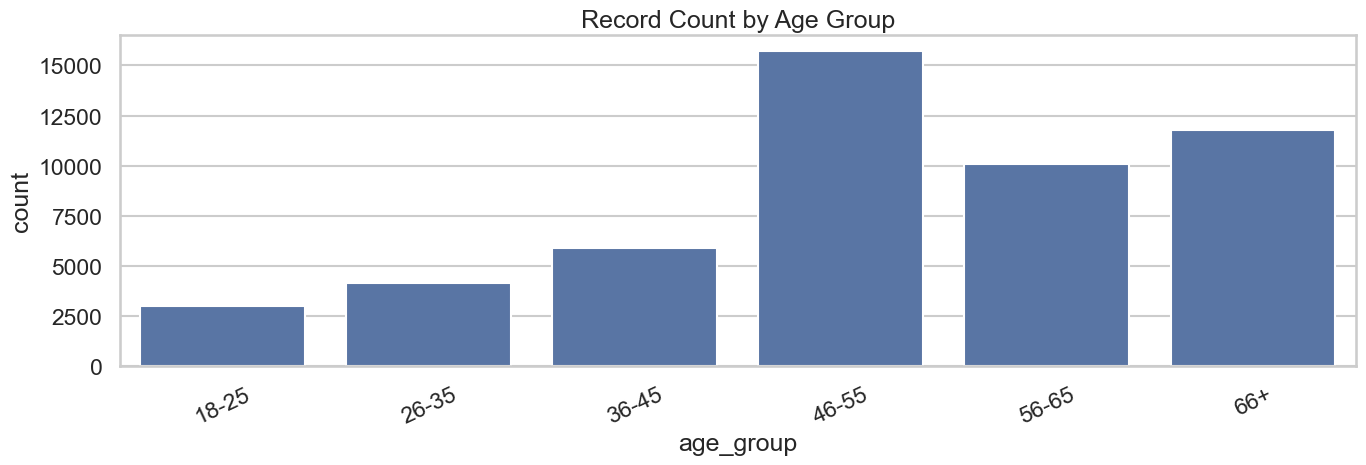

In [7]:
segment_cols = [c for c in [age_col, income_col, gender_col] if c is not None and c in df.columns]

if segment_cols:
    segment_counts = (
        df.groupby(segment_cols, observed=False)
          .size()
          .reset_index(name="segment_size")
          .sort_values("segment_size", ascending=False)
    )
    display(segment_counts.head(20))

    sparse_segments = segment_counts[segment_counts["segment_size"] < 50]
    print(f"Total unique segments: {len(segment_counts)}")
    print(f"Sparse segments (<50 records): {len(sparse_segments)}")
    if len(sparse_segments) > 0:
        display(sparse_segments.head(15))

if "age_group" in df.columns:
    plt.figure(figsize=(14, 5))
    order = [x for x in ['18-25', '26-35', '36-45', '46-55', '56-65', '66+'] if x in df['age_group'].astype(str).unique()]
    sns.countplot(data=df, x="age_group", order=order if order else None, color="#4c72b0")
    plt.xticks(rotation=25)
    plt.title("Record Count by Age Group")
    plt.tight_layout()
    plt.show()

## EDA Deep Dive 2: Numeric Distributions and Outlier Scan

Here we review core numeric features to detect skewness and extreme values that may affect model stability.
The outlier summary helps decide whether capping or robust scaling is needed.

Numeric columns used for deep distribution scan:
['time_completed', 'time_viewed', 'age', 'income', 'days_since_registration', 'transaction_count', 'total_spent', 'avg_transaction_value', 'membership_duration_months', 'spend_per_transaction']


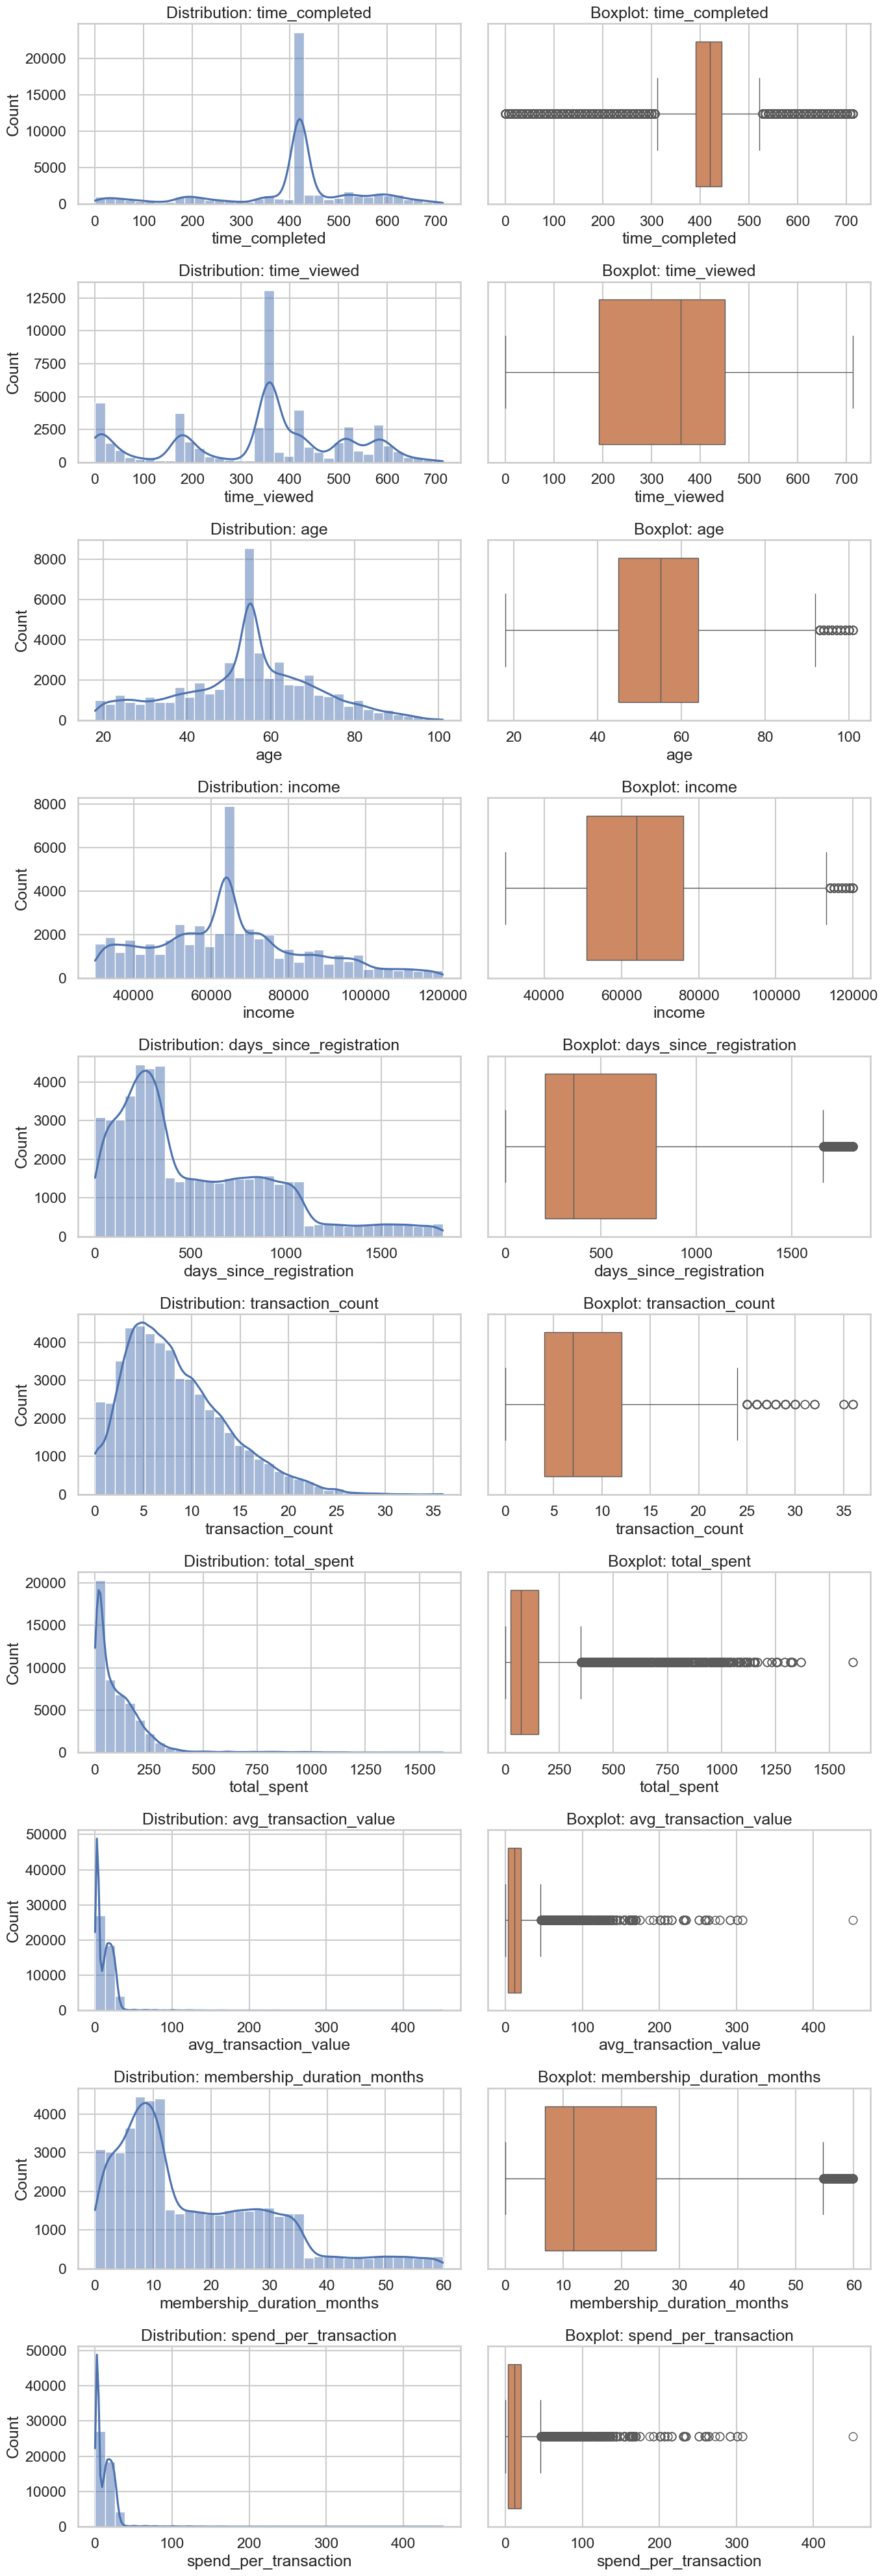

In [8]:
candidate_numeric = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude mostly-binary flags for clearer continuous distribution diagnostics
analysis_numeric = []
for c in candidate_numeric:
    uniq = df[c].nunique(dropna=True)
    if uniq > 12 and df[c].notna().mean() > 0.8:
        analysis_numeric.append(c)
analysis_numeric = analysis_numeric[:10]

print("Numeric columns used for deep distribution scan:")
print(analysis_numeric)

if analysis_numeric:
    fig, axes = plt.subplots(len(analysis_numeric), 2, figsize=(14, 4 * len(analysis_numeric)))
    if len(analysis_numeric) == 1:
        axes = np.array([axes])

    for i, col in enumerate(analysis_numeric):
        sns.histplot(df[col], kde=True, bins=35, ax=axes[i, 0], color="#4c72b0")
        axes[i, 0].set_title(f"Distribution: {col}")

        sns.boxplot(x=df[col], ax=axes[i, 1], color="#dd8452")
        axes[i, 1].set_title(f"Boxplot: {col}")

    plt.tight_layout()
    plt.show()

    outlier_rows = []
    for col in analysis_numeric:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_pct = ((df[col] < lower) | (df[col] > upper)).mean() * 100
        outlier_rows.append({
            "feature": col,
            "outlier_pct": round(float(outlier_pct), 2),
            "lower_bound": round(float(lower), 3),
            "upper_bound": round(float(upper), 3)
        })

    outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
    outlier_summary

## EDA Deep Dive 3: Correlation and Redundancy

This section highlights strongly related numeric variables.
Highly correlated features can be reduced to avoid redundancy and improve model interpretability.

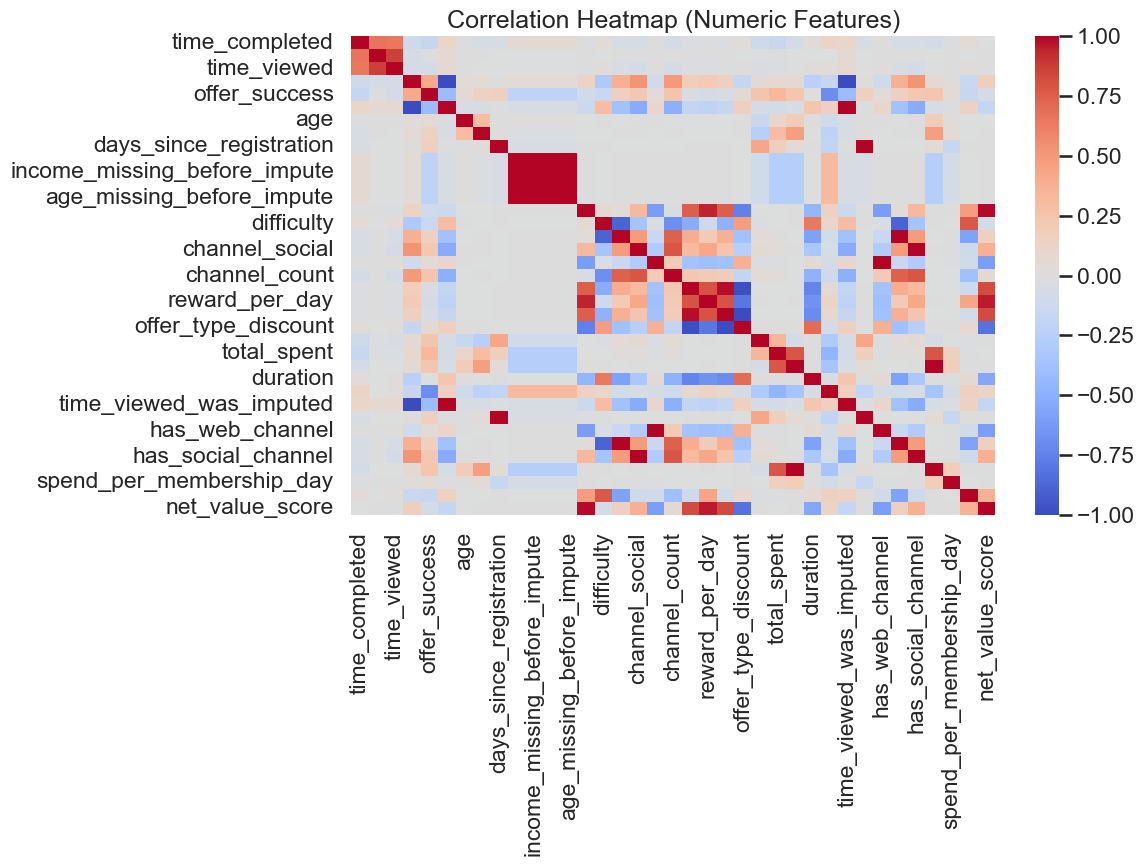

,feature_1,feature_2,corr_abs
1,was_viewed,received_not_viewed,-1.000
2,was_viewed,time_viewed_was_imputed,-1.000
3,received_not_viewed,time_viewed_was_imputed,1.000
5,age_was_118,income_missing_before_impute,1.000
4,days_since_registration,membership_duration_months,1.000
6,age_was_118,gender_missing_before_fill,1.000
7,age_was_118,age_missing_before_impute,1.000
21,offer_type_bogo,offer_type_discount,-1.000
8,income_missing_before_impute,gender_missing_before_fill,1.000
9,income_missing_before_impute,age_missing_before_impute,1.000


In [9]:
# Correlation on non-constant numeric columns
corr_cols = [c for c in candidate_numeric if df[c].nunique(dropna=True) > 1]
corr_df = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr_df, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

high_corr_pairs = []
for i, c1 in enumerate(corr_df.columns):
    for c2 in corr_df.columns[i + 1:]:
        val = corr_df.loc[c1, c2]
        if abs(val) >= 0.85:
            high_corr_pairs.append((c1, c2, round(float(val), 3)))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "corr_abs"])
if len(high_corr_df) == 0:
    print("No very-high correlation pairs (|r| >= 0.85) found.")
else:
    display(high_corr_df.sort_values("corr_abs", key=np.abs, ascending=False))

## EDA Deep Dive 4: Offer Journey Funnel

This section tracks conversion path quality from exposure to success and identifies stage drop-offs.

,stage,records,rate_pct
0,received,50637,100.00
1,viewed,39826,78.65
2,successful,19740,38.98


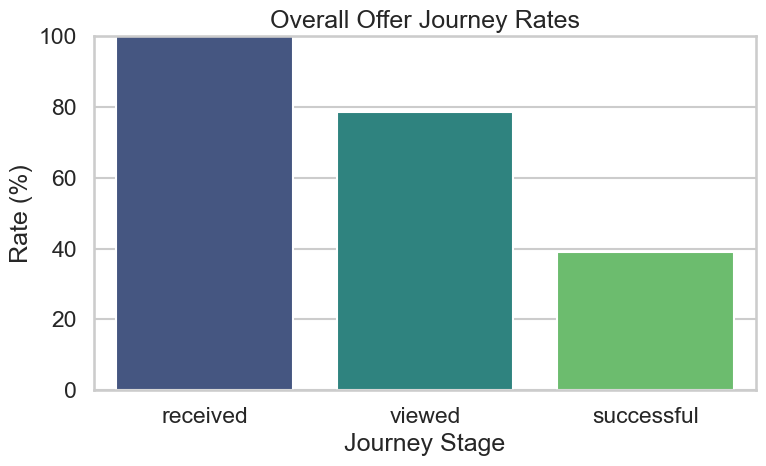

,offer_type,viewed_rate,success_rate,records
0,bogo,85.09,36.34,25321
1,discount,72.21,41.63,25316


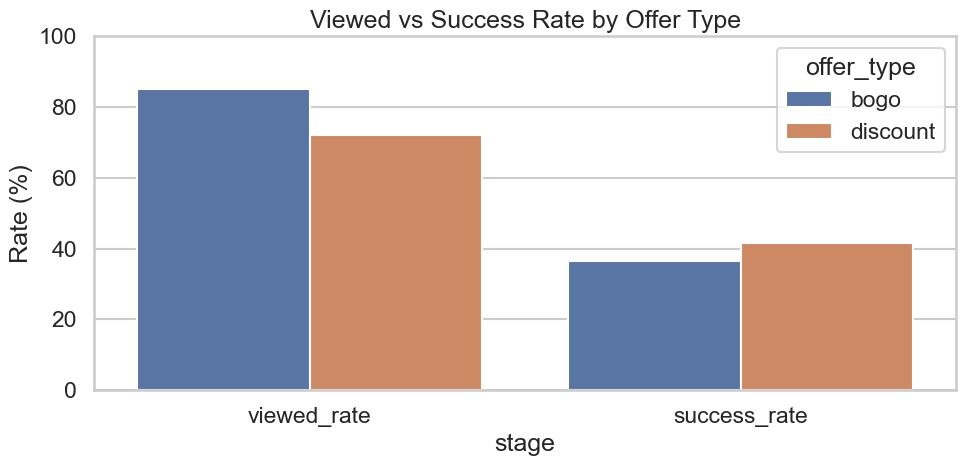

In [10]:
# Build funnel stages from available columns
stage_map = []

if "time_received" in df.columns:
    stage_map.append(("received", df["time_received"].notna()))
elif "received_not_viewed" in df.columns or "was_viewed" in df.columns:
    stage_map.append(("received", pd.Series(True, index=df.index)))

if "was_viewed" in df.columns:
    stage_map.append(("viewed", pd.to_numeric(df["was_viewed"], errors="coerce").fillna(0).astype(int) == 1))
elif "offer_viewed" in df.columns:
    stage_map.append(("viewed", pd.to_numeric(df["offer_viewed"], errors="coerce").fillna(0).astype(int) == 1))

stage_map.append(("successful", pd.to_numeric(df[success_col], errors="coerce").fillna(0).astype(int) == 1))

funnel_df = pd.DataFrame({
    "stage": [s for s, _ in stage_map],
    "records": [int(mask.sum()) for _, mask in stage_map]
})
funnel_df["rate_pct"] = (funnel_df["records"] / len(df) * 100).round(2)
display(funnel_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=funnel_df, x="stage", y="rate_pct", hue="stage", palette="viridis", legend=False)
plt.ylim(0, 100)
plt.title("Overall Offer Journey Rates")
plt.ylabel("Rate (%)")
plt.xlabel("Journey Stage")
plt.tight_layout()
plt.show()

if "offer_type" in df.columns and "was_viewed" in df.columns:
    type_funnel = df.groupby("offer_type", observed=False).agg(
        viewed_rate=("was_viewed", "mean"),
        success_rate=(success_col, "mean"),
        records=(success_col, "count")
    ).reset_index()
    type_funnel[["viewed_rate", "success_rate"]] = type_funnel[["viewed_rate", "success_rate"]] * 100
    display(type_funnel.round(2))

    melt_tf = type_funnel.melt(id_vars=["offer_type", "records"], value_vars=["viewed_rate", "success_rate"], var_name="stage", value_name="rate_pct")
    plt.figure(figsize=(10, 5))
    sns.barplot(data=melt_tf, x="stage", y="rate_pct", hue="offer_type")
    plt.title("Viewed vs Success Rate by Offer Type")
    plt.ylabel("Rate (%)")
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

## EDA Deep Dive 5: Customer-Level Behavior View

This creates one row per customer to inspect behavior patterns at person level.
It is useful because modeling and business actions are often customer-centric.

Customer-level table shape: (16928, 9)


,offers_count,completion_rate,unique_offers,avg_reward,avg_difficulty,avg_duration,avg_income,avg_age,avg_total_spent
count,16928.00,16928.00,16928.00,16928.00,16928.00,16928.00,16928.00,16928.00,16928.00
mean,2.99,39.14,2.99,5.26,9.64,7.26,65234.70,54.48,104.64
std,1.00,35.38,1.00,1.64,2.45,0.98,20180.88,16.24,126.11
min,1.00,0.00,1.00,2.00,5.00,5.00,30000.00,18.00,0.00
25%,2.00,0.00,2.00,4.00,7.50,6.50,51000.00,45.00,21.86
50%,3.00,33.33,3.00,5.00,9.25,7.25,64000.00,55.00,69.57
75%,4.00,66.67,4.00,6.00,11.25,8.00,76000.00,65.00,149.01
max,6.00,100.00,6.00,10.00,20.00,10.00,120000.00,101.00,1608.69


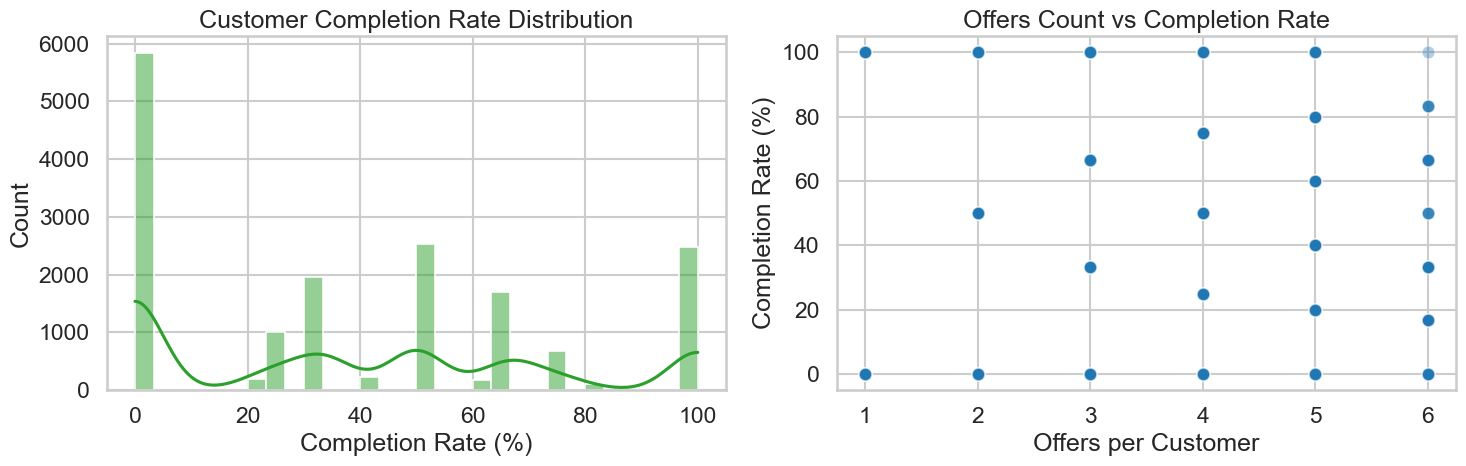

,customers,avg_completion_rate,avg_offers
value_tier,,,
low_response,11786,19.60,2.99
high_response,5142,83.92,3.00


In [11]:
# Build customer-level table for targeting and CRM strategy
if "person" not in df.columns:
    raise ValueError("Expected 'person' column for customer-level analysis.")

offer_id_col = "offer_id" if "offer_id" in df.columns else ("offer" if "offer" in df.columns else None)

agg_ops = {
    "offers_count": (success_col, "count"),
    "completion_rate": (success_col, "mean")
}
if offer_id_col is not None:
    agg_ops["unique_offers"] = (offer_id_col, "nunique")
if "reward" in df.columns:
    agg_ops["avg_reward"] = ("reward", "mean")
if "difficulty" in df.columns:
    agg_ops["avg_difficulty"] = ("difficulty", "mean")
if "duration" in df.columns:
    agg_ops["avg_duration"] = ("duration", "mean")
if "income" in df.columns:
    agg_ops["avg_income"] = ("income", "mean")
if "age" in df.columns:
    agg_ops["avg_age"] = ("age", "mean")
if "total_spent" in df.columns:
    agg_ops["avg_total_spent"] = ("total_spent", "mean")

customer_df = df.groupby("person", observed=False).agg(**agg_ops)
customer_df["completion_rate"] = customer_df["completion_rate"] * 100

print(f"Customer-level table shape: {customer_df.shape}")
display(customer_df.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(customer_df["completion_rate"], bins=30, kde=True, ax=axes[0], color="#2ca02c")
axes[0].set_title("Customer Completion Rate Distribution")
axes[0].set_xlabel("Completion Rate (%)")

sns.scatterplot(data=customer_df.reset_index(), x="offers_count", y="completion_rate", alpha=0.35, ax=axes[1], color="#1f77b4")
axes[1].set_title("Offers Count vs Completion Rate")
axes[1].set_xlabel("Offers per Customer")
axes[1].set_ylabel("Completion Rate (%)")

plt.tight_layout()
plt.show()

# Simple actionable customer cohorts with duplicate-quantile-safe binning
customer_df = customer_df.reset_index()
quantile_edges = customer_df["completion_rate"].quantile([0, 1/3, 2/3, 1]).values
quantile_edges = np.unique(quantile_edges)

if len(quantile_edges) >= 4:
    labels = ["low_response", "mid_response", "high_response"]
    customer_df["value_tier"] = pd.cut(customer_df["completion_rate"], bins=quantile_edges, labels=labels, include_lowest=True)
elif len(quantile_edges) == 3:
    labels = ["low_response", "high_response"]
    customer_df["value_tier"] = pd.cut(customer_df["completion_rate"], bins=quantile_edges, labels=labels, include_lowest=True)
else:
    customer_df["value_tier"] = "single_tier"

cohort_summary = customer_df.groupby("value_tier", observed=False).agg(
    customers=("person", "count"),
    avg_completion_rate=("completion_rate", "mean"),
    avg_offers=("offers_count", "mean")
).round(2)
cohort_summary

## EDA Deep Dive 6: Modeling Readiness Checklist (Practical)

This final checklist identifies columns that may need dropping or encoding before training.
It focuses on leakage risk, constant columns, and basic feature engineering actions.

In [12]:
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
possible_id_cols = [c for c in df.columns if c.lower() in ["id", "person", "offer", "offer_id"] or c.endswith("_id")]
possible_leakage_cols = [c for c in ["completed_after_view", "within_offer_window", "time_completed"] if c in df.columns and c != success_col]

binary_cols = [
    c for c in df.columns
    if pd.api.types.is_numeric_dtype(df[c]) and set(df[c].dropna().unique()).issubset({0, 1})
]

modeling_checklist = {
    "constant_columns": constant_cols,
    "identifier_like_columns": possible_id_cols,
    "possible_leakage_columns": possible_leakage_cols,
    "binary_columns": binary_cols,
    "categorical_columns": df.select_dtypes(include=["object", "category"]).columns.tolist(),
}

print("=== Modeling Preparation Checklist ===")
for k, v in modeling_checklist.items():
    print(f"\n{k} ({len(v)}):")
    print(v[:20] if isinstance(v, list) else v)

prep_recommendations = [
    "Drop constant columns before training.",
    "Remove identifiers (person/offer/offer_id) from features.",
    "Exclude leakage-like columns tied directly to journey completion timing.",
    "One-hot encode remaining categorical features (or use native categorical model support).",
    "Use stratified split on success label and compare AUC + PR metrics.",
    "Evaluate segment-level performance fairness (age/income/gender cohorts).",
]

print("\nRecommended next pre-model steps:")
for i, rec in enumerate(prep_recommendations, 1):
    print(f"{i}. {rec}")

=== Modeling Preparation Checklist ===

constant_columns (3):
['channel_email', 'offer_type_informational', 'has_email_channel']

identifier_like_columns (2):
['person', 'offer_id']

possible_leakage_columns (3):
['completed_after_view', 'within_offer_window', 'time_completed']

binary_columns (26):
['was_viewed', 'completed_after_view', 'within_offer_window', 'offer_success', 'received_not_viewed', 'age_was_118', 'income_missing_before_impute', 'gender_missing_before_fill', 'age_missing_before_impute', 'channel_email', 'channel_mobile', 'channel_social', 'channel_web', 'offer_type_bogo', 'offer_type_discount', 'offer_type_informational', 'time_completed_was_imputed', 'time_viewed_was_imputed', 'has_web_channel', 'has_email_channel']

categorical_columns (6):
['person', 'offer_id', 'age_group', 'income_group', 'gender_inferred', 'offer_type']

Recommended next pre-model steps:
1. Drop constant columns before training.
2. Remove identifiers (person/offer/offer_id) from features.
3. Excl

## Actionable Marketing Playbook

This section auto-generates practical recommendations from the EDA results:
- Who to target first (demographic segments)
- Which offer type to prioritize
- Which channels to emphasize
- Which customer-value cohort deserves different campaign treatment

In [13]:
# 1) Top demographic targets by success rate with minimum sample size guard
min_segment_size = 300
target_dims = [c for c in [age_col, income_col, gender_col] if c is not None and c in df.columns]

if target_dims:
    seg_perf = (
        df.groupby(target_dims, observed=False)
          .agg(records=(success_col, 'count'), success_rate=(success_col, 'mean'))
          .reset_index()
    )
    seg_perf['success_rate_pct'] = (seg_perf['success_rate'] * 100).round(2)
    seg_perf = seg_perf[seg_perf['records'] >= min_segment_size].sort_values('success_rate_pct', ascending=False)
    top_segments = seg_perf.head(10)
    print('Top target segments (records >=', min_segment_size, '):')
    display(top_segments)

# 2) Offer-type prioritization
offer_strategy = offer_perf[['offer_type', 'success_rate', 'records']].copy() if 'offer_perf' in globals() else pd.DataFrame()
if not offer_strategy.empty:
    offer_strategy = offer_strategy.sort_values('success_rate', ascending=False)
    print('Offer type prioritization:')
    display(offer_strategy.round(2))

# 3) Channel mix prioritization (deduplicated logical channels)
if 'channel_summary_df' in globals() and not channel_summary_df.empty:
    def normalize_channel_name(name):
        n = str(name).replace('has_', '').replace('channel_', '')
        return n
    ch = channel_summary_df.copy()
    ch['channel_norm'] = ch['channel'].apply(normalize_channel_name)
    ch = ch.groupby('channel_norm', as_index=False).agg(
        records=('records', 'max'),
        success_rate=('success_rate', 'mean')
    ).sort_values('success_rate', ascending=False)
    print('Channel strategy ranking:')
    display(ch.round(2))

# 4) Cohort-level message strategy
if 'cohort_summary' in globals():
    print('Customer value cohorts:')
    display(cohort_summary)

# 5) Auto-generated concise action list
actions = []
if 'offer_strategy' in locals() and not offer_strategy.empty:
    best_offer = offer_strategy.iloc[0]['offer_type']
    actions.append(f'Prioritize {best_offer} campaigns as primary conversion driver.')
if 'ch' in locals() and len(ch) > 0:
    top_channel = ch.iloc[0]['channel_norm']
    actions.append(f'Increase emphasis on {top_channel} channel for high-response audiences.')
if 'top_segments' in locals() and len(top_segments) > 0:
    seg_row = top_segments.iloc[0]
    seg_desc = ', '.join([f"{col}={seg_row[col]}" for col in target_dims])
    actions.append(f'Primary target segment: {seg_desc}.')
if 'cohort_summary' in globals() and hasattr(cohort_summary, 'index') and len(cohort_summary) > 0:
    actions.append('Differentiate campaign pressure by value tier: protect high_response tier and re-activate low_response tier.')

print('=== Recommended Marketing Actions ===')
for i, a in enumerate(actions, 1):
    print(f'{i}. {a}')

Top target segments (records >= 300 ):


,age_group,income_group,gender_inferred,records,success_rate,success_rate_pct
28,36-45,upper_middle,M,442,0.592760,59.28
71,66+,upper_middle,M,1061,0.552309,55.23
24,36-45,middle,F,663,0.552036,55.20
42,46-55,upper_middle,F,1046,0.523901,52.39
38,46-55,middle,F,1215,0.520165,52.02
43,46-55,upper_middle,M,872,0.517202,51.72
56,56-65,upper_middle,F,1292,0.515480,51.55
70,66+,upper_middle,F,1518,0.515152,51.52
53,56-65,middle,F,1408,0.514205,51.42
67,66+,middle,F,1764,0.512472,51.25


Offer type prioritization:


,offer_type,success_rate,records
1,discount,41.63,25316
0,bogo,36.34,25321


Channel strategy ranking:


,channel_norm,records,success_rate
5,social_channel,31623,47.53
4,social,31623,47.53
3,mobile_channel,44263,41.98
2,mobile,44263,41.98
6,web,44263,39.63
7,web_channel,44263,39.63
0,email,50637,38.98
1,email_channel,50637,38.98


Customer value cohorts:


,customers,avg_completion_rate,avg_offers
value_tier,,,
low_response,11786,19.60,2.99
high_response,5142,83.92,3.00


=== Recommended Marketing Actions ===
1. Prioritize discount campaigns as primary conversion driver.
2. Increase emphasis on social_channel channel for high-response audiences.
3. Primary target segment: age_group=36-45, income_group=upper_middle, gender_inferred=M.
4. Differentiate campaign pressure by value tier: protect high_response tier and re-activate low_response tier.
